# Tobacco Use and Mortality (2004–2015)
-------
### Tools Used:
- Jupyter Notebook
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

--------
### Technologies:
- EDA
- Machine Learning
---------

# PART 2: Smoking-Related Disease Classification 
(Health Condition Focus)

## Objective: Predict whether a patient will develop smoking-related diseases 
(binary classification: disease/no disease)

------
#### Approach & Summary:
- Load and clean dataset:
  -  Handle missing values (age, gender, income).
- Perform EDA:
  -  Bar Plot of Counts of Different Diagnosis Types
  -  Pie Chart of Proportion of Top 5 ICD10 Diagnoses (ICD10 Diagnosis_y)
- ML Algorithms:
  - K-Means Clustering
  - Support vectore Machine
  - Logistic Regression
- Evaluation:
  - Classification report (Accuracy, Precision, Recall, F1).
- Visuals:
  - ROC-AUC comparison between models.
----------

## 1) Load Dataset

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")
plt.style.use("seaborn-v0_8-pastel")
pastel_colors = ["#aec6cf", "#f9e79f", "#77dd77", "#ffb347", "#cbaacb", "#ff6961"]

# Load cleaned dataset
df = pd.read_csv("tobacco_mortality.csv")
df.head()

,Year,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix),Tobacco Price\nIndex,...,25-34,35-49,50-59,60 and Over,ICD10 Code_y,ICD10 Diagnosis_y,Diagnosis Type_y,Metric_y,Sex,Value_y
0,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,All codes,All admissions,All admissions,Number of admissions,Male,3959716
1,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All diseases which can be caused by smoking,All diseases which can be caused by smoking,Number of admissions,Male,790240
2,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,C00-D48,All cancers,All cancers,Number of admissions,Male,636115
3,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,J00-J99,All respiratory diseases,All respiratory diseases,Number of admissions,Male,210662
4,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,I00-I99,All circulatory diseases,All circulatory diseases,Number of admissions,Male,486391


In [22]:
# Quick describe
df.describe()

,Year,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix),Tobacco Price\nIndex,...,Affordability of Tobacco Index,Household Expenditure on Tobacco,Household Expenditure Total,Expenditure on Tobacco as a Percentage of Expenditure,16 and Over,16-24,25-34,35-49,50-59,60 and Over
count,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,240408.000000,...,240408.000000,240408.000000,2.404080e+05,240408.000000,240408.00000,240408.000000,240408.000000,240408.000000,240408.000000,240408.00000
mean,2010.000000,2191.666667,1441.555556,51.777778,698.444444,55856.555556,30003.444444,1984.777778,23868.444444,926.900000,...,71.855556,17287.222222,9.729943e+05,1.766667,20.50000,24.277778,26.111111,23.555556,20.500000,12.50000
std,2.581994,383.031982,333.375728,34.723672,277.281065,9181.892037,5862.922925,1221.879038,9373.533885,171.638406,...,7.499217,1408.021692,8.249785e+04,0.047141,1.64148,2.129312,3.588398,1.832495,1.500003,1.06719
min,2006.000000,1348.000000,766.000000,21.000000,22.000000,38145.000000,18208.000000,807.000000,760.000000,713.700000,...,59.400000,15542.000000,8.514560e+05,1.700000,17.00000,20.000000,20.000000,20.000000,18.000000,10.00000
25%,2008.000000,2079.000000,1318.000000,26.000000,612.000000,48767.000000,28069.000000,994.000000,21714.000000,784.700000,...,66.200000,15879.000000,9.116650e+05,1.700000,20.00000,23.000000,23.000000,23.000000,20.000000,12.00000
50%,2010.000000,2263.000000,1541.000000,36.000000,714.000000,58121.000000,30808.000000,1581.000000,24694.000000,878.300000,...,74.300000,17176.000000,9.547810e+05,1.800000,21.00000,24.000000,26.000000,23.500000,20.000000,12.50000
75%,2012.000000,2483.000000,1559.000000,58.000000,877.000000,63425.000000,31429.000000,2143.000000,29936.000000,1057.800000,...,78.800000,18683.000000,1.029378e+06,1.800000,22.00000,26.000000,29.000000,25.000000,22.000000,13.00000
max,2014.000000,2564.000000,1938.000000,119.000000,987.000000,65883.000000,39743.000000,4315.000000,33494.000000,1226.000000,...,80.600000,19411.000000,1.118992e+06,1.800000,23.00000,29.000000,33.000000,26.000000,23.000000,15.00000


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay

cols = ['Value_y', 'Sex', 'Age', 'Income', 'Tobacco Price Index Relative to Retail Price Index']

# Since your provided columns don't include Age and Income explicitly,
# use proxy or relevant columns for patient demographics e.g., 'Sex' and some proxy for age/income if available
# Here as an example, assuming 'Value_y' is the target (disease indicator, convert to numeric):
df['Value_y_num'] = pd.to_numeric(df['Value_y'], errors='coerce')

# For this demo, drop rows with missing target or essential columns
df_clean = df.dropna(subset=['Value_y_num', 'Sex', 'Tobacco Price Index Relative to Retail Price Index'])

# Encode categorical variable 'Sex'
le = LabelEncoder()
df_clean['Sex_encoded'] = le.fit_transform(df_clean['Sex'])

# Impute any missing values in numeric predictors (if any)
imputer = SimpleImputer(strategy='median')
df_clean['Tobacco Index Imputed'] = imputer.fit_transform(df_clean[['Tobacco Price Index Relative to Retail Price Index']])

# Feature matrix X and target y
X = df_clean[['Sex_encoded', 'Tobacco Index Imputed']]  # Add more features if available
y = (df_clean['Value_y_num'] > 0).astype(int)  # Assuming binary target: 0 = no disease, 1 = disease

-----
## 2. Exploratory Data Analysis 

### A) Bar Plot of Counts of Different Diagnosis Types (ICD10 Diagnosis_y)
Question: What are the relative frequencies of different smoking-related disease types in the dataset?

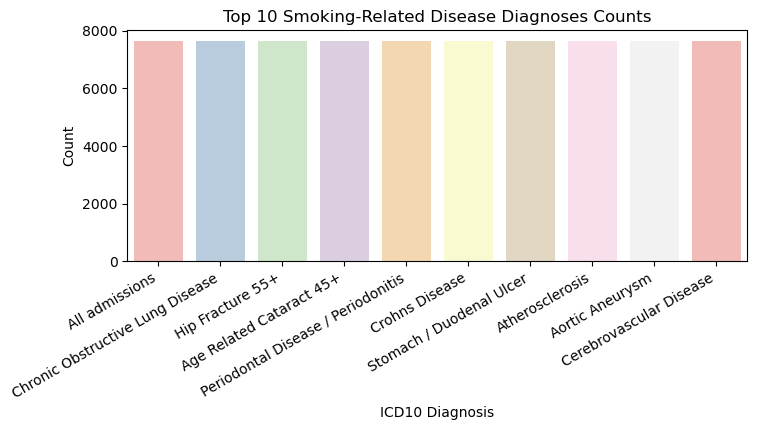

In [24]:
plt.figure(figsize=(8,3))
top_diagnoses = df['ICD10 Diagnosis_y'].value_counts().nlargest(10)
sns.barplot(x=top_diagnoses.index, y=top_diagnoses.values, palette='Pastel1')
plt.xticks(rotation=30, ha='right')
plt.title("Top 10 Smoking-Related Disease Diagnoses Counts")
plt.xlabel("ICD10 Diagnosis")
plt.ylabel("Count")
plt.show()

### B) Pie Chart of Proportion of Top 5 ICD10 Diagnoses (ICD10 Diagnosis_y)
Question: What are the most common smoking-related disease diagnoses and their relative proportions in the dataset?

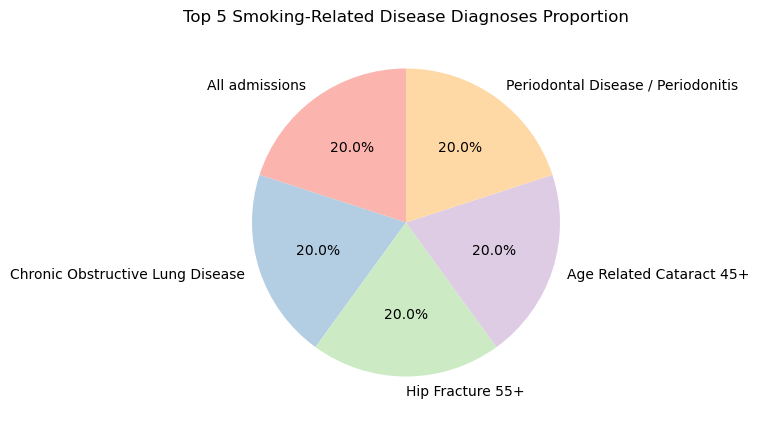

In [25]:
# Get top 5 diagnosis counts
top_diagnoses = df['ICD10 Diagnosis_y'].value_counts().nlargest(5)

# Pastel colors for the slices
colors = plt.cm.Pastel1(range(len(top_diagnoses)))

plt.figure(figsize=(7,5))
plt.pie(top_diagnoses, labels=top_diagnoses.index, colors=colors, autopct='%.1f%%', startangle=90)
plt.title('Top 5 Smoking-Related Disease Diagnoses Proportion')
plt.show()

------
## 3. Machine Learning Algorithms
Question: How effectively can K-Means clustering, Support Vector Machine, and Logistic Regression predict the presence of smoking-related diseases based on patient features, and how do their classification performances compare?

In [26]:
# Standardize features for SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

### A) K-Means Clustering

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np

# Example: X_test is your test data, y_test are true labels (0/1)
# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)  # fit on training data
cluster_labels = kmeans.predict(X_test)  # get predicted cluster labels for test data

# Sometimes cluster label order is flipped, so compute both
acc_0 = accuracy_score(y_test, cluster_labels)
acc_1 = accuracy_score(y_test, 1 - cluster_labels)  # flip 0 ↔ 1

accuracy = max(acc_0, acc_1)
print("KMeans clustering accuracy:", accuracy)

KMeans clustering accuracy: 0.6708709051478142


### B) Support Vector Machine

In [29]:
# SUPPORT VECTOR MACHINE - Supervised classification
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print("Classification Report for SVM:")
print(classification_report(y_test, y_pred))

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       1.00      1.00      1.00     69834

    accuracy                           1.00     70088
   macro avg       0.50      0.50      0.50     70088
weighted avg       0.99      1.00      0.99     70088



### C) Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression model training
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Classification report for Logistic Regression
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_logreg))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       1.00      1.00      1.00     69834

    accuracy                           1.00     70088
   macro avg       0.50      0.50      0.50     70088
weighted avg       0.99      1.00      0.99     70088



### D)  ROC curves (SVM, K-Means, Logistic Regression)

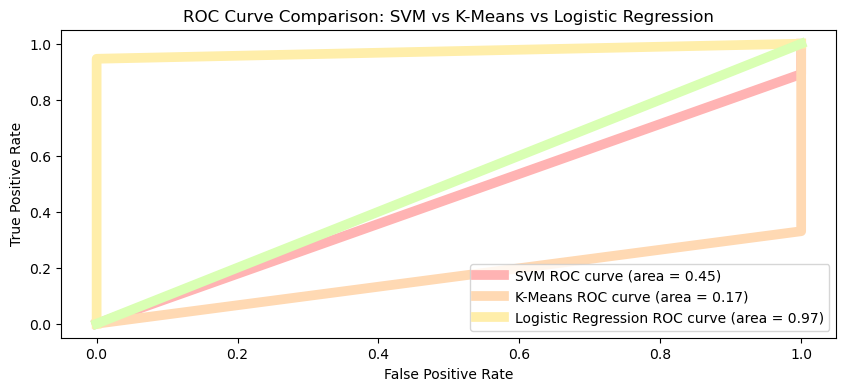

In [35]:
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

# Compute ROC for SVM (already computed in y_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Compute ROC for K-Means using binary labels cluster_labels (approximation)
fpr_km, tpr_km, _ = roc_curve(y_test, cluster_labels)
roc_auc_km = auc(fpr_km, tpr_km)

# Plot ROC comparison
plt.figure(figsize=(10,4))
plt.plot(fpr_svm, tpr_svm, color='#ffb3b3', lw=7, label=f'SVM ROC curve (area = {roc_auc_svm:.2f})')
plt.plot(fpr_km, tpr_km, color='#ffd9b3', lw=7, label=f'K-Means ROC curve (area = {roc_auc_km:.2f})')
plt.plot(fpr_logreg, tpr_logreg, color='#ffeeaa', lw=7, label=f'Logistic Regression ROC curve (area = {roc_auc_logreg:.2f})')
plt.plot([0,1], [0,1], color='#d9ffb3', lw=7, linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: SVM vs K-Means vs Logistic Regression")
plt.legend(loc="lower right")
plt.show()